<a href="https://colab.research.google.com/github/akorzun159/retail-peak-hours-analysis/blob/main/retail_peak_hours_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Online_Retail.csv', encoding='latin-1')

In [39]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


По первоначальному анализу данных можно понять, что столбец 'InvoiceDate' имеет тип данных object. Работать с таким типом данных будет неудобно, поэтому сразу проведет преобразование к другому типу данных

In [41]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%y %H:%M')

Добавим новый столбец 'Revenue', который будет показывать выручку с каждого заказа

In [42]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

В рамках исследования будем исследовать пиковые часы. Для этого создадим новый столбец, который будет содержать час, в который совершена покупка

In [43]:
df['Hour'] = df['InvoiceDate'].dt.hour

Рассчитаем общую выручку за каждый час

In [60]:
hourly_revenue = df.groupby('Hour')['Revenue'].sum().sort_values(ascending=False).reset_index()
hourly_revenue

,Hour,Revenue
0,12,1362484.290
1,10,1329056.521
2,15,1189458.280
3,13,1177506.370
4,11,1147437.920
5,14,1095212.901
6,9,766734.051
7,16,729140.820
8,17,435444.111
9,8,281840.860


Период времени с 10:00 по 15:00 оказался самым прибыльным. Каждый час из этого промежутка принес более 1 млн единиц валюты (к сожалению, в датасете не указано какая именно валюта используется). Самыми не прибыльными часами оказались 6:00 и 20:00. В 6:00 мы получили отрицательное значение выручки, соответственно, можно сделать вывод о том, что были возвраты

Также предлагается найти самый прибыльный час (пиковый)

In [45]:
best_hour_revenue = hourly_revenue.idxmax()
best_hour_revenue

np.int32(12)

В 12:00 выручка является максимальной. Следовательно 12:00 является пиковым часом по выручке

Посчитаем количество заказов за каждый час

In [61]:
hourly_orders = df.groupby('Hour')['InvoiceNo'].nunique().sort_values(ascending=False).reset_index()
hourly_orders

,Hour,InvoiceNo
0,12,3962
1,13,3369
2,11,3165
3,14,3137
4,15,3069
5,10,2961
6,16,1952
7,9,1824
8,17,1205
9,8,624


Полученные данные коррелирует с теми, что мы получили при подсчете выручку. Период времени с 10:00 по 15:00 показал наибольшее число заказов. В каждый час из этого промежутка совершалось более 3000 заказов (В 10:00 было совершено 2961 заказов, но округлим). Часами с наименьшим числом заказов являются 6:00 и 20:00, поэтому почасовая выручка наименьшая

Также предлагается найти самый активный час (пиковый)

In [47]:
best_hour_orders = hourly_orders.idxmax()
best_hour_orders

np.int32(12)

12:00 является самым активным (пиковым) часом

Визуализация

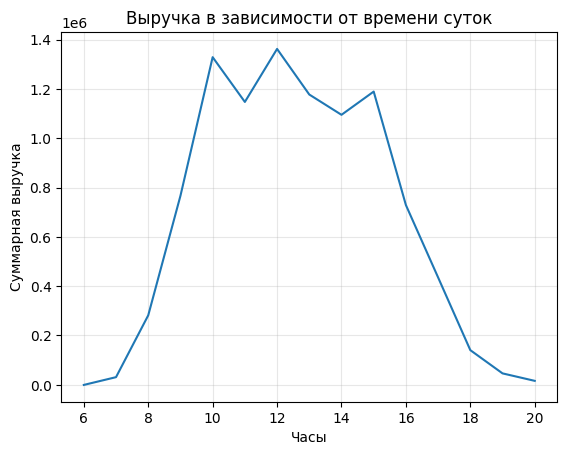

In [72]:
sns.lineplot(data=hourly_revenue, x='Hour', y='Revenue')
plt.grid(alpha=0.3)
plt.xlabel('Часы')
plt.ylabel('Суммарная выручка')
plt.title('Выручка в зависимости от времени суток')
plt.show()

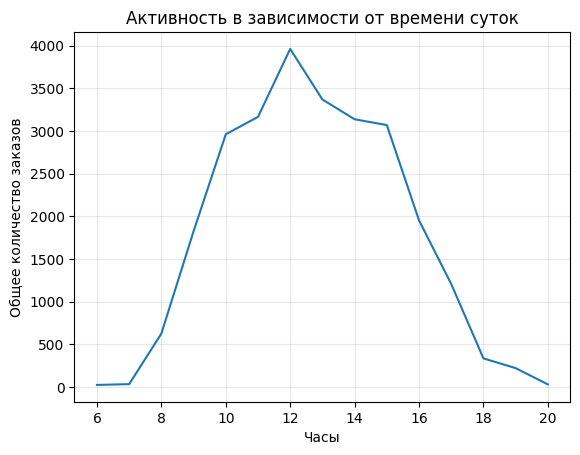

In [73]:
sns.lineplot(data=hourly_orders, x='Hour', y='InvoiceNo')
plt.grid(alpha=0.3)
plt.xlabel('Часы')
plt.ylabel('Общее количество заказов')
plt.title('Активность в зависимости от времени суток')
plt.show()

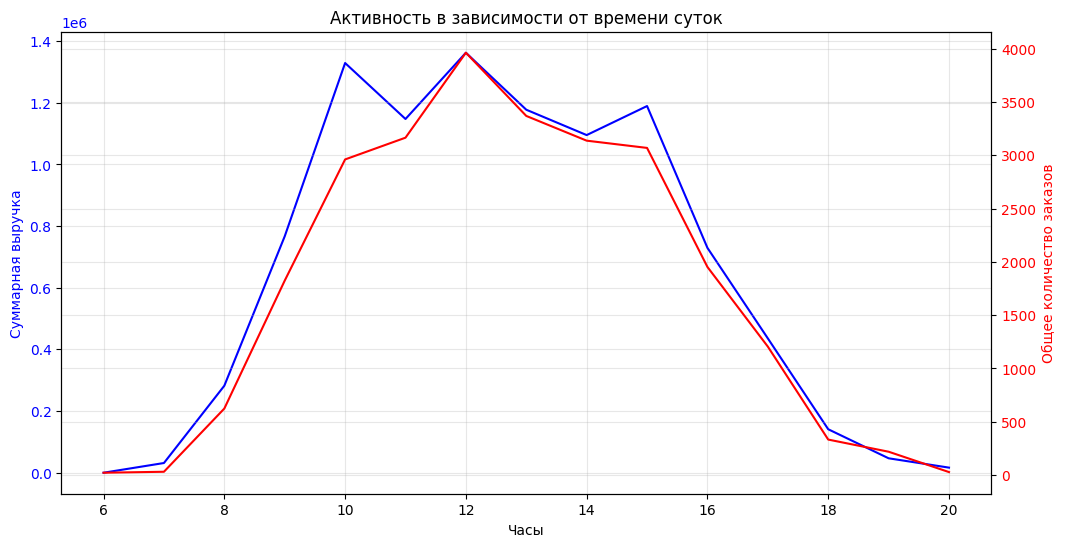

In [81]:
fig, ax1 = plt.subplots(figsize=(12,6))

sns.lineplot(data=hourly_revenue, x='Hour', y='Revenue', ax=ax1, color='blue')
ax1.set_xlabel('Часы')
ax1.set_ylabel('Суммарная выручка', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(alpha=0.3)


ax2 = ax1.twinx()
sns.lineplot(data=hourly_orders, x='Hour', y='InvoiceNo', ax=ax2, color='red')
ax2.set_ylabel('Общее количество заказов', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.grid(alpha=0.3)

plt.title('Активность в зависимости от времени суток')
plt.show()

Проведенный анализ почасовой активности интернет-магазина показал, что пик выручки и наибольшее количество заказов приходятся на 12:00, при этом период с 10:00 до 15:00 является самым прибыльным и активно приносит более миллиона единиц валюты за каждый час. Наименьшая активность наблюдается в 6:00 и 20:00, причем в 6:00 зафиксирована отрицательная выручка, что может указывать на возвраты товаров в это время. Таким образом, основная масса покупок совершается клиентами в рабочее время, вероятно, в обеденный перерыв, что позволяет рекомендовать усиление маркетинговой активности в промежутке с 10:00 до 15:00 для максимизации прибыли, а также проведение дополнительного анализа причин возвратов в ранние утренние часы.